# Plot CLM surfdata changes and final PFT distributions

This standalone notebook requires only two CLM surface datasets:

1. the original surface dataset;
2. the modified surface dataset produced from the LPJ-GUESS FPC anomaly.

It calculates the realised change directly as `final − original` and produces
two independent six-panel figures for natural bare ground and five selected
natural PFTs: `[0, 2, 3, 8, 11, 12]`.

The change is expressed in **percentage points of the CLM natural landunit**,
not as a relative percentage change.

## 1. Setup

Upload or copy both NetCDF files into the notebook directory, then edit the two
paths below. Figures are saved as PNG and PDF.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 11,
    "axes.titlesize": 12,
})

In [2]:
DATA = Path("/nird/datapeak/NS9188K/adelez/BRL-FRST-XPSN/data/edit-surfdata")
ORIGINAL_SURFDATA = DATA / "surfdata_1.9x2.5_hist_78pfts_CMIP6_simyr2000_c190304.nc"
FINAL_SURFDATA = DATA / "surfdata_1.9x2.5_SSP5-8.5_2100_78pfts_LPJGUESS.nc"

FIGURE_DIR = Path("figures")
SAVE_FIGURES = True
CHANGE_TOLERANCE = 1e-8
PFTS_TO_PLOT = [8, 2, 3, 11, 12, 0]

PFT_NAMES = {
    0: "BG",
    2: "BoNET",
    3: "BoNDT",
    8: "BoBDT",
    11: "BoBDS",
    12: "aC3",
}

for path in [ORIGINAL_SURFDATA, FINAL_SURFDATA]:
    if not path.exists():
        raise FileNotFoundError(f"Upload the file or update its path: {path}")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load and validate both surface datasets

The coordinate conversion places both files on the same `lat`, `lon`, and
`natpft` axes before subtraction. The checks prevent plots from being produced
from mismatched grids or invalid PFT partitions.

In [3]:
def convert_lsmcoord(dataset):
    if {"lat", "lon"}.issubset(dataset.dims):
        return dataset
    required = {"lsmlat", "lsmlon", "LATIXY", "LONGXY"}
    if not required.issubset(set(dataset.dims) | set(dataset.variables)):
        raise ValueError("Could not identify CLM latitude and longitude coordinates")
    converted = dataset.assign_coords(
        lsmlat=dataset["LATIXY"].isel(lsmlon=0).values,
        lsmlon=dataset["LONGXY"].isel(lsmlat=0).values,
    )
    return converted.rename({"lsmlat": "lat", "lsmlon": "lon"})


def convert360_180(data):
    if float(data.lon.min()) >= 0:
        data = data.assign_coords(
            lon=((data.lon + 180) % 360) - 180
        ).sortby("lon")
    return data


def load_pct_nat_pft(path):
    with xr.open_dataset(path) as dataset:
        if "PCT_NAT_PFT" not in dataset:
            raise KeyError(f"PCT_NAT_PFT is missing from {path}")
        pct = convert360_180(convert_lsmcoord(dataset)["PCT_NAT_PFT"])
        required_dims = {"natpft", "lat", "lon"}
        if not required_dims.issubset(pct.dims):
            raise ValueError(f"Unexpected PCT_NAT_PFT dimensions in {path}: {pct.dims}")
        return pct.transpose("natpft", "lat", "lon").load()


pct_original = load_pct_nat_pft(ORIGINAL_SURFDATA)
pct_final = load_pct_nat_pft(FINAL_SURFDATA)
pct_original, pct_final = xr.align(pct_original, pct_final, join="exact")

missing_pfts = sorted(set(PFTS_TO_PLOT) - set(pct_original.natpft.values.tolist()))
if missing_pfts:
    raise ValueError(f"Requested natpft indices are absent: {missing_pfts}")

original_sum = pct_original.sum("natpft", skipna=False)
final_sum = pct_final.sum("natpft", skipna=False)
valid_domain = (
    np.isfinite(original_sum)
    & np.isfinite(final_sum)
    & (np.abs(original_sum - 100) < 1e-3)
    & (np.abs(final_sum - 100) < 1e-3)
)

if not bool(valid_domain.any()):
    raise ValueError("No grid cell has a valid 100% natural-PFT partition in both files")

partition_error = np.abs(final_sum - 100).where(valid_domain)
assert float(pct_final.where(valid_domain).min(skipna=True)) >= -1e-8
assert float(pct_final.where(valid_domain).max(skipna=True)) <= 100 + 1e-8
assert float(partition_error.max(skipna=True)) < 1e-6

## 3. Calculate the realised change and modification domain

The modification domain is inferred from the files: a valid grid cell is
included when at least one natural PFT differs by more than
`CHANGE_TOLERANCE`. This avoids any dependency on the LPJ-GUESS coverage mask
or the construction notebook.

In [4]:
realised_delta = pct_final - pct_original
maximum_cell_change = np.abs(realised_delta).max("natpft", skipna=False)
modify_domain = (valid_domain & (maximum_cell_change > CHANGE_TOLERANCE)).fillna(False)

if not bool(modify_domain.any()):
    raise ValueError("No modified grid cells were detected")

summary = pd.Series({
    "valid cells in both files": int(valid_domain.sum().item()),
    "modified cells": int(modify_domain.sum().item()),
    "change tolerance [percentage points]": CHANGE_TOLERANCE,
    "maximum partition residual [%]": float(partition_error.max(skipna=True).item()),
    "maximum absolute PFT change [percentage points]": (
        float(maximum_cell_change.where(modify_domain).max(skipna=True).item())
    ),
})
display(summary)

valid cells in both files                          1.382400e+04
modified cells                                     1.161000e+03
change tolerance [percentage points]               1.000000e-08
maximum partition residual [%]                     9.947598e-14
maximum absolute PFT change [percentage points]    5.780000e+01
dtype: float64

## 4. Plotting functions

Both figures use the same Arctic projection and a shared discrete colourbar.
The plotting function returns the colourbar explicitly, so percentage labels
do not depend on the order of Matplotlib axes.

In [5]:
def circular_boundary(ax):
    angle = np.linspace(0, 2 * np.pi, 200)
    vertices = np.column_stack([np.sin(angle), np.cos(angle)]) * 0.5 + 0.5
    ax.set_boundary(mpath.Path(vertices), transform=ax.transAxes)


def save_figure(fig, name):
    if not SAVE_FIGURES:
        return
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=220, bbox_inches="tight", transparent=True)
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")


def discrete_scale(cmap_name, levels, under=None, over=None):
    cmap = plt.get_cmap(cmap_name, len(levels) - 1)
    extremes = {}
    if under is not None:
        extremes["under"] = under
    if over is not None:
        extremes["over"] = over
    if extremes:
        cmap = cmap.with_extremes(**extremes)
    return cmap, mcolors.BoundaryNorm(levels, cmap.N, clip=False)


def map_panel(
    fields,
    panel_titles,
    colorbar_label,
    cmap,
    norm,
    figure_title,
    ticks=None,
    extend="both",
    ncols=3,
):
    nrows = int(np.ceil(len(fields) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(3.7 * ncols, 3.7 * nrows + 0.7),
        subplot_kw={"projection": ccrs.Orthographic(0, 90)},
        layout="constrained",
    )
    axes = np.atleast_1d(axes).ravel()

    image = None
    for ax, field, title in zip(axes, fields, panel_titles):
        ax.set_extent([-180, 180, 45, 90], ccrs.PlateCarree())
        circular_boundary(ax)
        image = field.plot.pcolormesh(
            ax=ax,
            x="lon",
            y="lat",
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            norm=norm,
            add_colorbar=False,
        )
        ax.coastlines(linewidth=0.45, color="0.2")
        ax.gridlines(linewidth=0.4, color="0.65", alpha=0.35)
        ax.set_title(title)

    for ax in axes[len(fields):]:
        ax.set_visible(False)

    fig.suptitle(figure_title, fontsize=14)
    colorbar = fig.colorbar(
        image,
        ax=list(axes[:len(fields)]),
        orientation="horizontal",
        ticks=ticks,
        fraction=0.045,
        pad=0.04,
        aspect=45,
        extend=extend,
    )
    colorbar.set_label(colorbar_label)
    return fig, colorbar


def add_percent_ticks(colorbar):
    colorbar.ax.xaxis.set_major_formatter(
        FuncFormatter(lambda value, position: f"{value:g}%")
    )


panel_titles = [f"{PFT_NAMES[pft]}" for pft in PFTS_TO_PLOT]

## 5. Realised PFT changes

The central colour interval spans −5 to +5 percentage points, placing zero in
the middle of the neutral colour. All non-zero labelled ticks coincide with
colour boundaries.

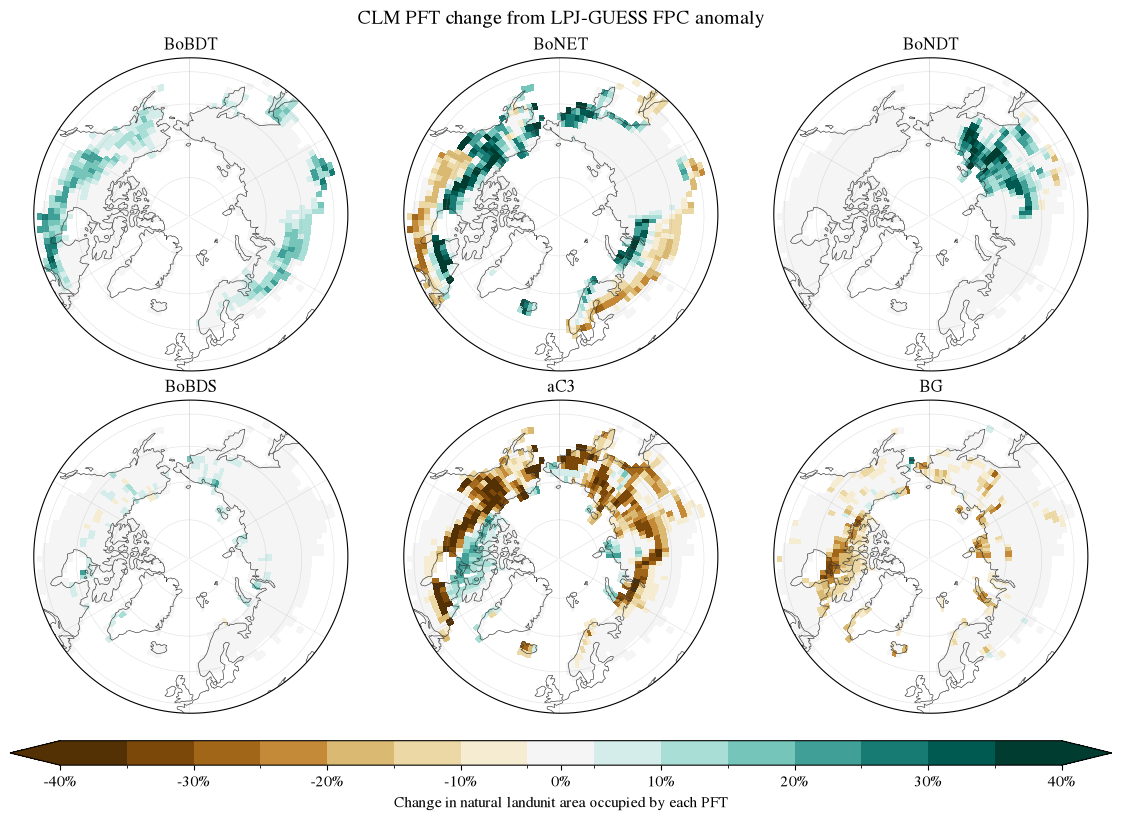

In [8]:
selected_change = realised_delta.sel(natpft=PFTS_TO_PLOT).where(modify_domain)
finite_change = np.abs(selected_change.values)
finite_change = finite_change[np.isfinite(finite_change)]
if finite_change.size == 0:
    raise ValueError("The selected PFTs contain no finite changes")

change_step = 5.0
change_limit = max(
    10.0,
    np.ceil(np.percentile(finite_change, 99) / 10.0) * 10.0,
)
change_levels = np.r_[
    np.arange(-change_limit, 0, change_step),
    np.arange(change_step, change_limit + change_step, change_step),
]
change_ticks = np.arange(-change_limit, change_limit + 10.0, 10.0)
change_cmap, change_norm = discrete_scale("BrBG", change_levels)

fig, colorbar = map_panel(
    fields=[
        selected_change.sel(natpft=pft)
        for pft in PFTS_TO_PLOT
    ],
    panel_titles=panel_titles,
    colorbar_label="Change in natural landunit area occupied by each PFT",
    cmap=change_cmap,
    norm=change_norm,
    ticks=change_ticks,
    extend="both",
    figure_title="CLM PFT change from LPJ-GUESS FPC anomaly",
    ncols=3,
)
add_percent_ticks(colorbar)
save_figure(fig, "realised_pft_change")
fig.savefig("/cluster/home/adelez/boreal-forest-expantion-draft/figures/realised_pft_change.png", dpi=300, bbox_inches="tight", transparent=True)
plt.show()

## 6. Final PFT distribution

This figure shows the final percentage of the natural landunit occupied by the
same six classes, including natural bare ground (`natpft = 0`).

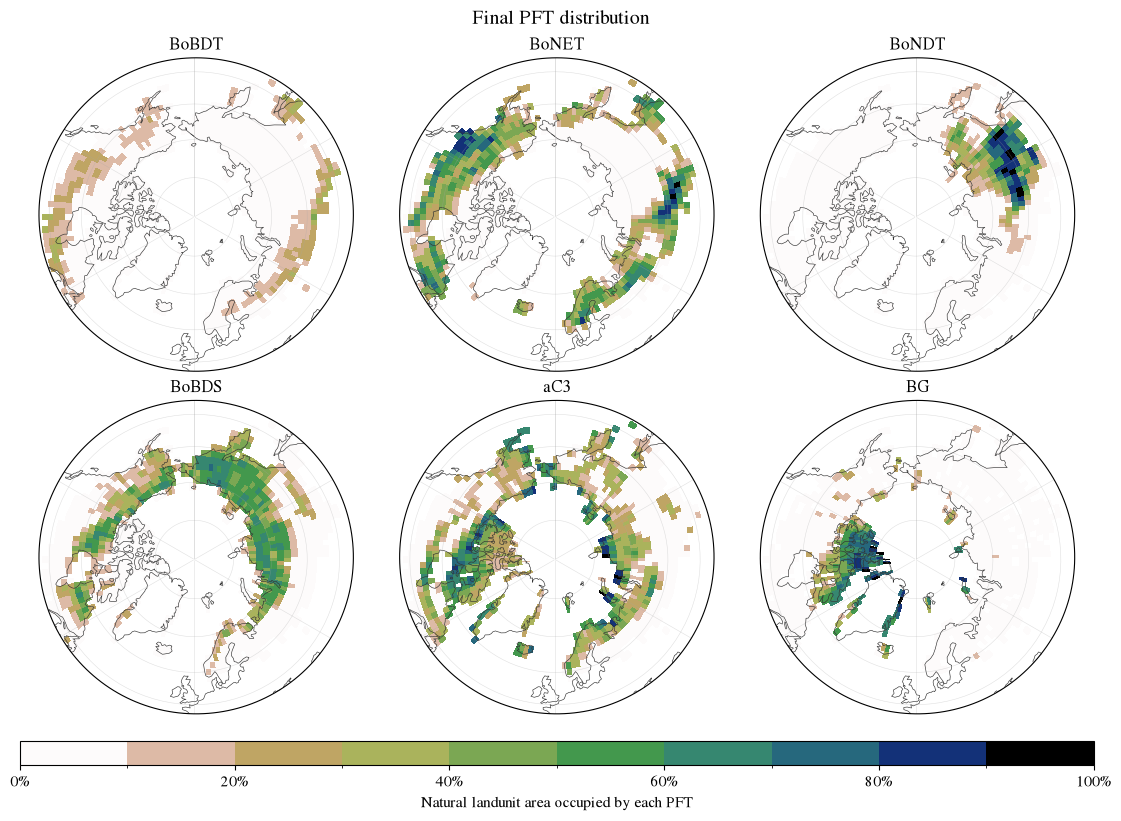

In [7]:
final_levels = np.arange(0, 101, 10)
final_ticks = np.arange(0, 101, 20)
final_cmap, final_norm = discrete_scale(
    "gist_earth_r",
    final_levels,
    under="white",
    over="black",
)

fig, colorbar = map_panel(
    fields=[
        pct_final.sel(natpft=pft).where(modify_domain)
        for pft in PFTS_TO_PLOT
    ],
    panel_titles=panel_titles,
    colorbar_label="Natural landunit area occupied by each PFT",
    cmap=final_cmap,
    norm=final_norm,
    ticks=final_ticks,
    extend="neither",
    figure_title="Final PFT distribution",
    ncols=3,
)
add_percent_ticks(colorbar)
save_figure(fig, "final_pft_distribution")
plt.show()